In [17]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

## Cosmology: Background and Perturbations

This code snippet initializes and computes the cosmological background and perturbations at various redshifts using the **CAMB** and **HMCode2020Emu** interfaces.

In [18]:
zs = np.linspace(1e-4, 3, 100)

background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545)
linear_perturbations = CAMBLinearPerturbations(background, zs)
nonlinear_perturbations = CAMBNonLinearPerturbations(background, zs, nonlinear_model = 'mead2020_feedback')
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, zs, log10TAGN=7.8)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


## Download and Read the Data

In this step, we use the `euclidlib` library to read the data. `euclidlib` provides the necessary functions and utilities to access and handle data from the Euclid mission, allowing us to seamlessly retrieve, process, and analyze the large datasets generated by the mission. 

For this tutorial, we use example synthetic data stored at https://zenodo.org/communities/cloe-org


In [ ]:
# Download the data

import requests

# URLs of the files to be downloaded
urls = {
    'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
    'cls_example.fits': 'https://zenodo.org/records/15092888/files/cls_example.fits',
    'mixmats_example.fits': 'https://zenodo.org/records/15092888/files/mixmats_example.fits'
}

# Function to download a file
def download_file(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f'{filename} downloaded successfully')
    else:
        print(f'Failed to download {filename}. Status code: {response.status_code}')

# Download all files
for filename, url in urls.items():
    download_file(url, filename)

nz_example.fits downloaded successfully
cls_example.fits downloaded successfully


In [23]:
z_nz, nz_example = el.photo.redshift_distributions('nz_example.fits')
cls_example = el.photo.angular_power_spectra('cls_example.fits')
#mixmats_example = el.photo.redshift_distributions('mixmats_example.fits')

## Plot the galaxy redshift distribution $n(z)$

And also normalise & interpolate!

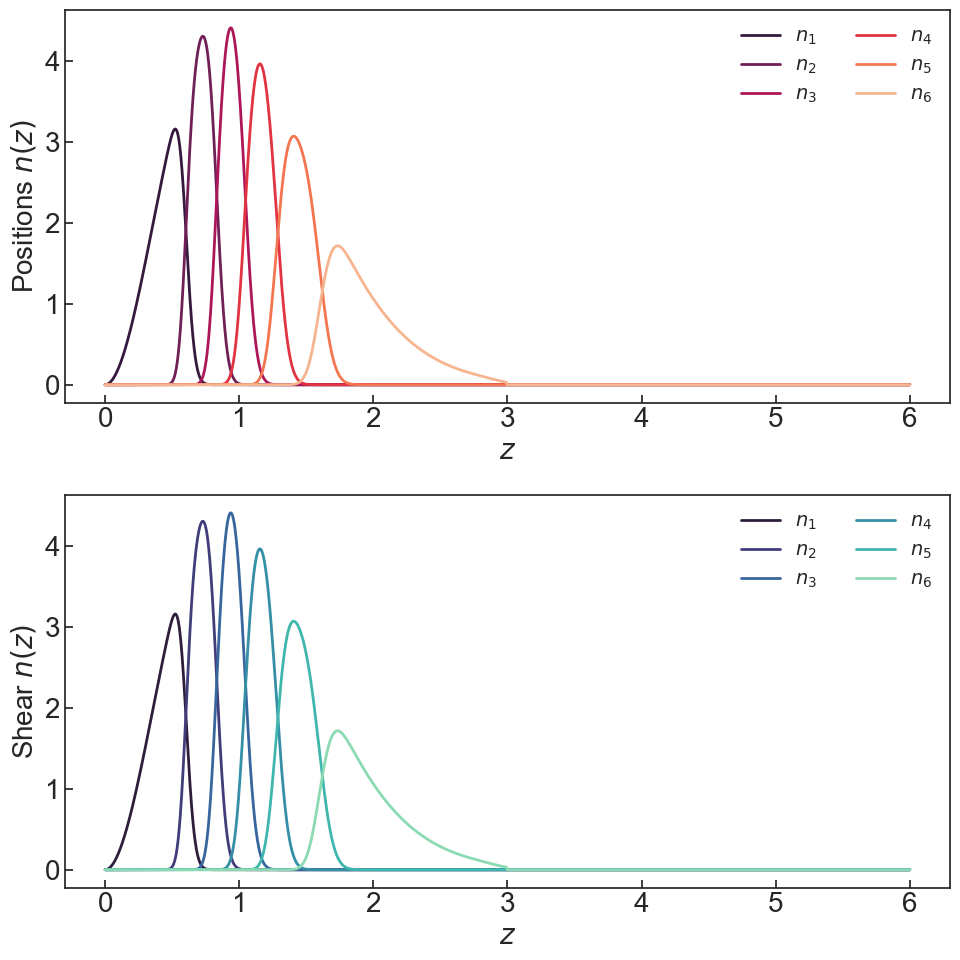

In [24]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_example, z_nz)
dndz_she_norm = normalize_dndz(nz_example, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
myz = np.linspace(1e-4, 3., 100)
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, myz)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, myz)

# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()



## Observables: shear and position tracers 

In [35]:
# Define the tracers

tracer_pos = PositionsTracer(perturbations=nonlinear_perturbations_emu, 
                             dndz=my_dndz_pos_norm,
                             z = myz)

tracer_she = ShearTracer(perturbations=nonlinear_perturbations_emu, 
                             dndz=my_dndz_she_norm,
                             z = myz,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41})

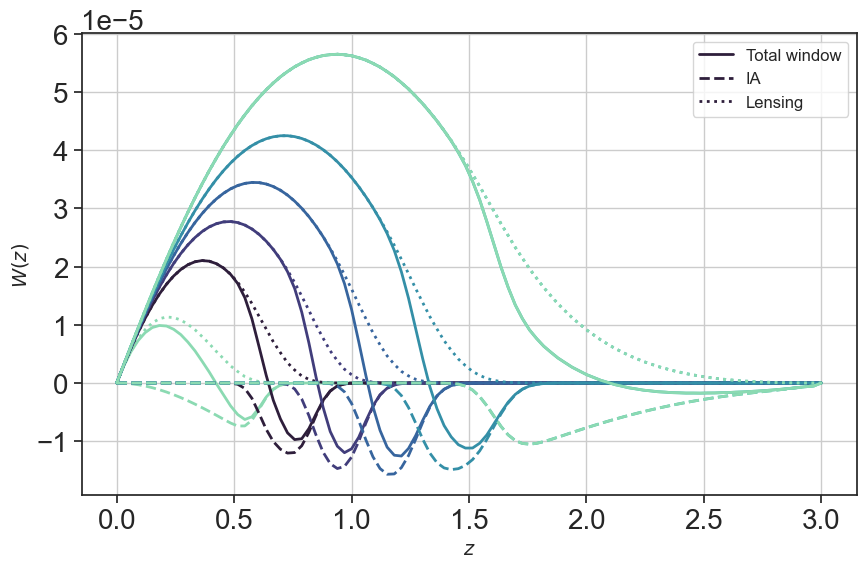

In [15]:
colors = sns.color_palette("mako", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop
for i in range(0, 7):
    # Plot the window
    plt.plot(nonlinear_perturbations.z, 
             tracer_she.get_window(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window
    plt.plot(nonlinear_perturbations.z, 
             tracer_she.get_window_IA(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'IA' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(nonlinear_perturbations.z, 
             tracer_she.get_lensing_window(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Lensing' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$W(z)$', fontsize=14)

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()


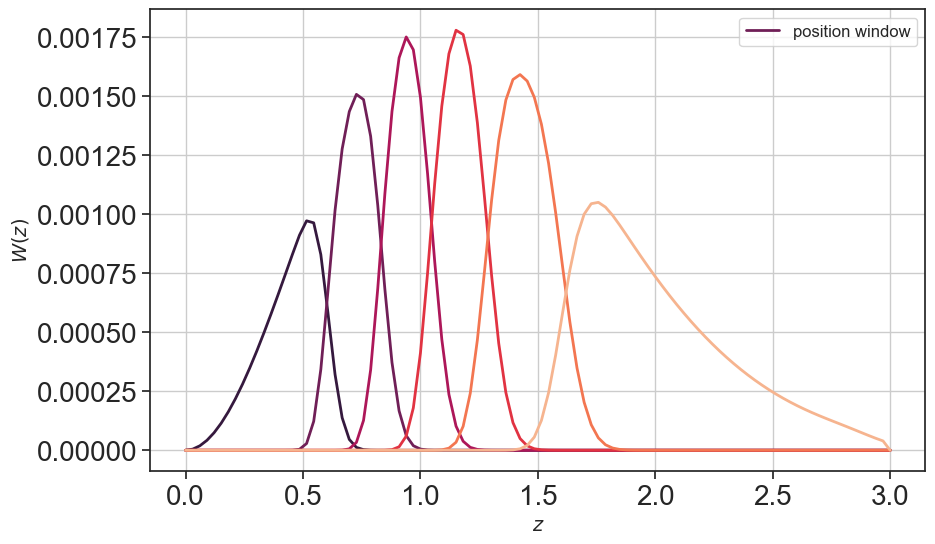

In [26]:
colors = sns.color_palette("rocket", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop
for i in range(0, 6):
    # Plot the window
    plt.plot(nonlinear_perturbations.z, 
             tracer_pos.get_window(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i], 
             label=f'position window' if i == 1 else "")
    

# Label the axes
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$W(z)$', fontsize=14)

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()

## Angular power spectra

### Theoretical Predictions

In [36]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_posshe = AngularTwoPoint(tracer_pos, tracer_she)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

cells_GG = twopoint_pospos.get_Cl(ells, 0, nonlinear_perturbations.k)
cells_GGL = twopoint_shepos.get_Cl(ells, 0, nonlinear_perturbations.k)
cells_EE = twopoint_sheshe.get_Cl(ells, 0, nonlinear_perturbations.k)

In [37]:
%timeit
cells_EE = twopoint_sheshe.get_Cl(ells, 0, nonlinear_perturbations.k)

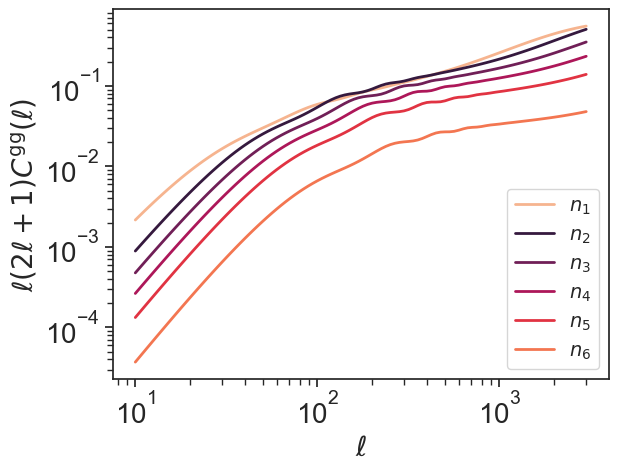

In [42]:
%timeit
for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*cells_GG[:, i, i], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$');
plt.legend(fontsize=14);

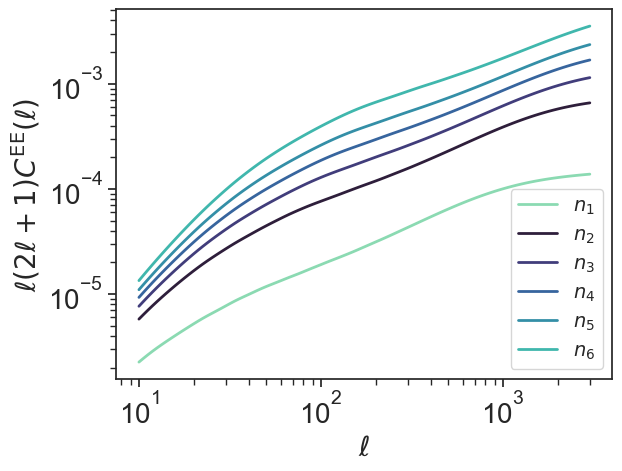

In [41]:
for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*cells_EE[:, i, i], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("mako", len(nz_example.keys()))[i-1])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm EE}(\ell)$');
plt.legend(fontsize=14);

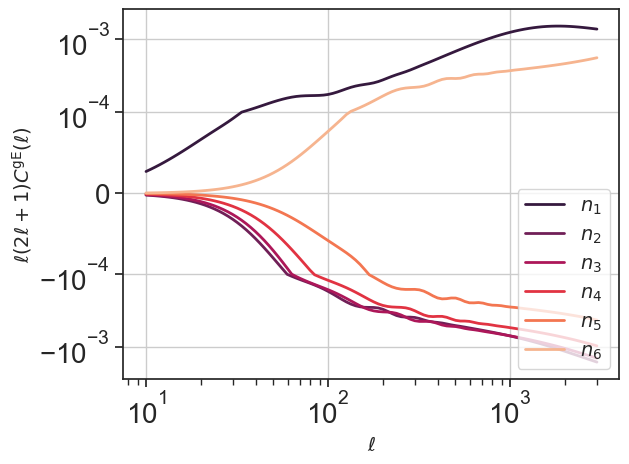

In [40]:
for i in range(0, 6):
    plt.plot(ells, 
             ells * (2 * ells + 1) * cells_GGL[:, i, i],
             label=f'$n_{{{i+1}}}$', 
             linewidth=2, 
             color=sns.color_palette("rocket", len(nz_example.keys()))[i])

# Labels and legend
plt.xlabel(r'$\ell$', fontsize=14)
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gE}(\ell)$', fontsize=14)
plt.legend(fontsize=14, loc=4)

# Set y-axis to symmetric log scale to handle negative values
plt.yscale('symlog', linthresh=1e-4)
plt.xscale('log')
# Show the grid and the plot
plt.grid(True)
plt.show()

### Data vectors

In [ ]:
cells_PP = twopoint_pospos.get_pseudo_Cl(0, nonlinear_perturbations.k, mixmat_example)

In [ ]:
plt.loglog(ell_cell,cells_data['POS','POS',0,0],'x')
plt.loglog(ells,cells_GG[:,0,0],label='$C_\ell$')
plt.loglog(ell_mixmat,cells_PP['POS','POS',0,0],label='pseudo $C_\ell$')

plt.legend()
plt.xlim([1,1500])

In [ ]:
cells_SS = twopoint_sheshe.get_pseudo_Cl(nl, nonlinear_perturbations.k,mixmat)

In [ ]:
plt.loglog(ell_cell,cells_data['SHE','SHE',0,0][:,0],'x')
plt.loglog(ells,cells_EE[:,0,0],label='$C_\ell$')
plt.loglog(ell_mixmat,cells_SS['SHE','SHE',0,0][0],label='pseudo $C_\ell$')

plt.legend()
plt.xlim([2,1500])

In [ ]:
cells_PS = twopoint_shepos.get_pseudo_Cl(nl, nonlinear_perturbations.k,mixmat)

In [ ]:
plt.semilogx(ell_cell,-cells_data['POS','SHE',0,0][:,0],'x')
plt.semilogx(ells,cells_GGL[:,0,0],label='$C_\ell$')
plt.semilogx(ell_mixmat,cells_PS['POS','SHE',0,0],label='pseudo $C_\ell$')

plt.legend()
plt.xlim([2,1500])
plt.ylim([-0.15e-7,0.15e-7])

In [ ]:
fig, ax = plt.subplots(6, 6, figsize=(12, 12), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            ell_cell[2:],
            cells_data["SHE", "SHE", i-1, j-1][2:,0],
            c="C0",
            lw=1.5,
            zorder=3.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            ell_mixmat[2:], cells_SS["SHE", "SHE", i-1, j-1][0, 2:], c="C0", lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].plot(
            ell_cell[2:],
            cells_data["SHE", "SHE", i-1, j-1][2:,1],
            c="C2",
            lw=1.5,
            zorder=1.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            ell_mixmat[2:], cells_SS["SHE", "SHE", i-1, j-1][1, 2:], c="C2", lw=1.0, zorder=2.0
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(1 / 3, 1500 * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-3e-10, 5e-9)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear $C_\\ell$", x=-0.1, ha="right")

plt.show()

### Test timing

In [ ]:
%%time

zs = np.linspace(1e-4, 3, 100)

background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545)
linear_perturbations = CAMBLinearPerturbations(background, zs)
pk_values_linear = linear_perturbations.matter_power_spectrum(linear_perturbations.z,linear_perturbations.k)

nonlinear_perturbations = CAMBNonLinearPerturbations(background, zs, nonlinear_model = 'mead2020_feedback')
pk_values_nonlinear = nonlinear_perturbations.matter_power_spectrum(nonlinear_perturbations.z,nonlinear_perturbations.k)

# Define the tracers

tracer_pos = PositionsTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = nonlinear_perturbations.z)

tracer_she = ShearTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_she_norm,
                             z = nonlinear_perturbations.z,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41})

nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

cells_GG_camb = twopoint_pospos.get_pseudo_Cl(0, nonlinear_perturbations.k,mixmat)
cells_GGL_camb = twopoint_shepos.get_pseudo_Cl(0, nonlinear_perturbations.k,mixmat)
cells_WL_camb = twopoint_sheshe.get_pseudo_Cl(0, nonlinear_perturbations.k,mixmat)

In [ ]:
%%time

zs = np.linspace(1e-4, 3, 100)

background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545)
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu,zs,log10TAGN=7.8)


pk_values_linear_emu = linear_perturbations_emu.matter_power_spectrum(linear_perturbations_emu.z,linear_perturbations_emu.k)

pk_values_nonlinear_emu = nonlinear_perturbations_emu.matter_power_spectrum(nonlinear_perturbations_emu.z,nonlinear_perturbations_emu.k)

# Define the tracers

tracer_pos = PositionsTracer(perturbations=nonlinear_perturbations_emu, 
                             dndz=my_dndz_pos_norm,
                             z = myz)

tracer_she = ShearTracer(perturbations=nonlinear_perturbations_emu, 
                             dndz=my_dndz_she_norm,
                             z = myz,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41})

nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

cells_GG_emu = twopoint_pospos.get_pseudo_Cl(0, nonlinear_perturbations_emu.k,mixmat,n_ells_int=50)
cells_GGL_emu = twopoint_shepos.get_pseudo_Cl(0, nonlinear_perturbations_emu.k,mixmat,n_ells_int=50)
cells_WL_emu = twopoint_sheshe.get_pseudo_Cl(0, nonlinear_perturbations_emu.k,mixmat)

In [ ]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

bin_plot = 6

# First plot: Power spectra
ax[0].loglog(ell_cell[2:],cells_WL_camb['SHE','SHE',bin_plot-1,bin_plot-1][0,2:], label='CAMB, HMCode2020', alpha=0.5)
ax[0].loglog(ell_cell[2:],cells_WL_emu['SHE','SHE',bin_plot-1,bin_plot-1][0,2:], '--', label='emu, HMCode2020')
ax[0].set_ylabel(r'$C_\ell^{EE}(%d,%d)$'%(bin_plot,bin_plot))
ax[0].legend()
ax[0].grid()

relative_diff = 100*(cells_WL_emu['SHE','SHE',bin_plot-1,bin_plot-1][0,2:] - cells_WL_camb['SHE','SHE',bin_plot-1,bin_plot-1][0,2:]) / cells_WL_camb['SHE','SHE',bin_plot-1,bin_plot-1][0,2:]

# Second plot: Relative difference
ax[1].semilogx(ell_cell[2:], relative_diff, 'k-', label=r'$\frac{C_\ell^{\mathrm{Emu}} - C_\ell^{\mathrm{CAMB}}}{C_\ell^{\mathrm{CAMB}}}$')
ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)
ax[1].set_xlabel(r'$\ell$ ')
ax[1].set_ylabel('Rel. Diff [%]')
ax[1].legend()
ax[1].grid()
ax[1].set_ylim([-0.3,0.3])

plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

bin_plot = 3

# First plot: Power spectra
ax[0].loglog(ell_cell[2:],cells_GG_camb['POS','POS',bin_plot-1,bin_plot-1][2:], label='CAMB, HMCode2020', alpha=0.5)
ax[0].loglog(ell_cell[2:],cells_GG_emu['POS','POS',bin_plot-1,bin_plot-1][2:], '--', label='emu, HMCode2020')

ax[0].set_ylabel(r'$C_\ell^{GG}(%d,%d)$'%(bin_plot,bin_plot))
ax[0].legend()
ax[0].grid()

relative_diff = 100*(cells_GG_emu['POS','POS',bin_plot-1,bin_plot-1][2:] - cells_GG_camb['POS','POS',bin_plot-1,bin_plot-1][2:]) / cells_GG_camb['POS','POS',bin_plot-1,bin_plot-1][2:]

# Second plot: Relative difference
ax[1].semilogx(ell_cell[2:], relative_diff, 'k-', label=r'$\frac{C_\ell^{\mathrm{Emu}} - C_\ell^{\mathrm{CAMB}}}{C_\ell^{\mathrm{CAMB}}}$')
ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)
ax[1].set_xlabel(r'$\ell$ ')
ax[1].set_ylabel('Rel. Diff [%]')
ax[1].legend()
ax[1].grid()
ax[1].set_ylim([-0.3,0.3])

plt.tight_layout()
plt.show()
